In [3]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.metrics import classification_report


warnings.filterwarnings('ignore')

print("--- 1. Przygotowanie Danych Głównego Notatnika ---")

# 1. Wczytanie pliku
df_final = pd.read_parquet('flight_data_ml_ready.parquet')

# 2. Separacja zmiennej docelowej (y) i cech (X)
y = df_final['TARGET_BAGGAGE']
target_cols = [col for col in df_final.columns if col.startswith('TARGET_')]
X = df_final.drop(columns=target_cols)

# 3. Oczyszczanie nazw kolumn (niezbędne dla LightGBM i dobra praktyka ogólna)
X = X.rename(columns=lambda x: re.sub('[^A-Za-z0-9_]+', '_', x))

# 4. Podział na zbiór treningowy i testowy (Stratify utrzymuje proporcje klas)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dane gotowe! Zbiór treningowy: {X_train.shape[0]} wierszy, Zbiór testowy: {X_test.shape[0]} wierszy.")
print(f"Ilość cech analitycznych: {X_train.shape[1]}")

--- 1. Przygotowanie Danych Głównego Notatnika ---
Dane gotowe! Zbiór treningowy: 422357 wierszy, Zbiór testowy: 105590 wierszy.
Ilość cech analitycznych: 468


In [4]:
import xgboost as xgb
from sklearn.metrics import precision_recall_curve

print("--- 3. Trenowanie Modelu: XGBoost (Wysoka Precyzja) ---")

# Obliczenie balansu dla XGBoost
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

xgb_model = xgb.XGBClassifier(
    n_estimators=150, max_depth=6, learning_rate=0.1,
    scale_pos_weight=pos_weight, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# Szukanie optymalnego progu (cel biznesowy: Precision > 30%)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs_xgb)

target_precision = 0.30
try:
    optimal_idx = np.where(precisions >= target_precision)[0][0]
    optimal_threshold = thresholds[optimal_idx]
except IndexError:
    optimal_idx = np.argmax(precisions)
    optimal_threshold = thresholds[optimal_idx]

# Aplikacja nowego progu
y_pred_xgb_optimal = (y_probs_xgb >= optimal_threshold).astype(int)

print(f"Ustalono nowy próg decyzyjny: {optimal_threshold*100:.1f}%")
print("\n[RAPORT KLASYFIKACJI - XGBoost (Threshold Tuned)]:")
print(classification_report(y_test, y_pred_xgb_optimal, target_names=['Brak bagażu (0)', 'Kupi bagaż (1)']))

--- 3. Trenowanie Modelu: XGBoost (Wysoka Precyzja) ---
Ustalono nowy próg decyzyjny: 80.4%

[RAPORT KLASYFIKACJI - XGBoost (Threshold Tuned)]:
                 precision    recall  f1-score   support

Brak bagażu (0)       0.96      0.98      0.97    100332
 Kupi bagaż (1)       0.30      0.20      0.24      5258

       accuracy                           0.94    105590
      macro avg       0.63      0.59      0.60    105590
   weighted avg       0.93      0.94      0.93    105590



--- 6. Wyjaśnialność Modelu (SHAP) ---
Analizuję myśli modelu XGBoost dla pierwszych 1000 wierszy testowych...


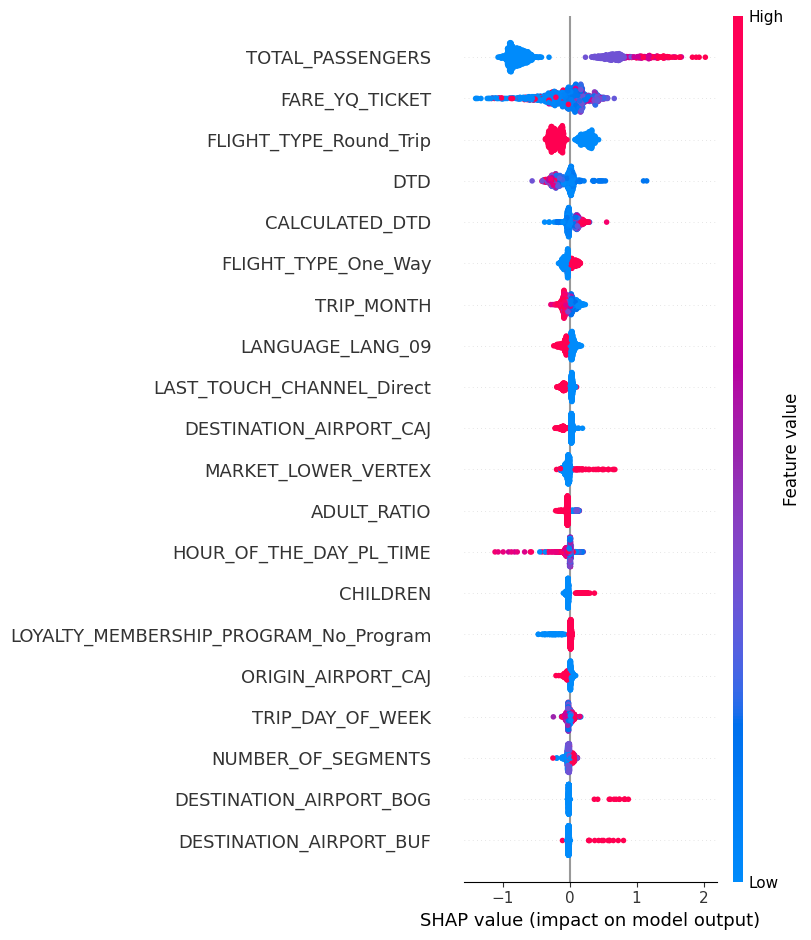

In [5]:
import shap

print("--- 6. Wyjaśnialność Modelu (SHAP) ---")
print("Analizuję myśli modelu XGBoost dla pierwszych 1000 wierszy testowych...")

# Wycinek danych, by oszczędzić czas (1000 wierszy)
X_sample = X_test.head(1000)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_sample)

# Rysowanie głównego wykresu SHAP
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample)